***IPL / Sports Data Analysis***

 Objective: Analyze IPL team performance using CSV datasets
Details:Calculate total runs, averages, and visualize team comparisons.
Learning Outcomes:
Apply groupby and aggregate functions.
Gain experience with large CSV data handling.
 Develop storytelling through visualization.

Importing python libraries and datasets


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [23]:
url="https://raw.githubusercontent.com/shafiyakhan11/IPL-data-Analysis-/refs/heads/main/IPL2025Batters.csv?token=GHSAT0AAAAAAEFGXA5J2U7YKHI6LQN44I2W2UWWHAA"
df = pd.read_csv(url)
print(df)



HTTPError: HTTP Error 404: Not Found

In [27]:
#df = pd.read_csv("/content/IPL2025Batters.csv")
show = df.head()
show

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37


In [5]:
team_runs = df.groupby('Team')['Runs'].sum().reset_index()
team_runs = team_runs.sort_values(by='Runs', ascending=False)
print("Total Runs by Team:\n", team_runs)

Total Runs by Team:
    Team  Runs
6  PBKS  3000
5    MI  2802
2    GT  2766
4   LSG  2598
7   RCB  2539
8    RR  2496
1    DC  2386
9   SRH  2378
0   CSK  2315
3   KKR  1886


In [26]:
url_2="https://raw.githubusercontent.com/shafiyakhan11/IPL-data-Analysis-/refs/heads/main/IPL2025Bowlers.csv?token=GHSAT0AAAAAAEFGXA5JPI7KN3ABW7WHBXGQ2UWWOIA"
df_2 = pd.read_csv(url_2)

print(df_2)

HTTPError: HTTP Error 404: Not Found

In [7]:
print(df_2.head())

       Player Name  Team  WKT  MAT  INN   OVR  RUNS   BBI    AVG   ECO     SR  \
0  Prasidh Krishna    GT   25   15   15  59.0   488  41/4  19.52  8.27  14.16   
1       Noor Ahmad   CSK   24   14   14  50.0   408  18/4  17.00  8.16  12.50   
2   Josh Hazlewood   RCB   22   12   12  44.0   386  33/4  17.54  8.77  12.00   
3      Trent Boult    MI   22   16   16  57.4   517  26/4  23.50  8.96  15.72   
4   Arshdeep Singh  PBKS   21   17   16  58.2   518  16/3  24.66  8.88  16.66   

   4W  5W  
0   1   0  
1   2   0  
2   1   0  
3   1   0  
4   0   0  


In [8]:
team_Matches = df.groupby('Team')['Matches'].sum().reset_index()
print("Total Matches by Team:\n", team_Matches)

Total Matches by Team:
    Team  Matches
0   CSK      153
1    DC      149
2    GT      156
3   KKR      139
4   LSG      155
5    MI      165
6  PBKS      176
7   RCB      149
8    RR      161
9   SRH      136


In [9]:
team_Wickets = df_2.groupby('Team')['WKT'].sum().reset_index()
print("Total Wickets by Team:\n", team_Wickets)

Total Wickets by Team:
    Team  WKT
0   CSK   80
1    DC   67
2    GT   87
3   KKR   78
4   LSG   76
5    MI  109
6  PBKS   95
7   RCB   91
8    RR   65
9   SRH   81


In [10]:
team_stats = pd.merge(team_runs, team_Matches,  on='Team')
team_stats

,Team,Runs,Matches
0,PBKS,3000,176
1,MI,2802,165
2,GT,2766,156
3,LSG,2598,155
4,RCB,2539,149
5,RR,2496,161
6,DC,2386,149
7,SRH,2378,136
8,CSK,2315,153
9,KKR,1886,139


In [11]:
team_stats['average'] = team_stats['Runs'] / team_stats['Matches']
print("Team Performance Statistics:\n", team_stats)

Team Performance Statistics:
    Team  Runs  Matches    average
0  PBKS  3000      176  17.045455
1    MI  2802      165  16.981818
2    GT  2766      156  17.730769
3   LSG  2598      155  16.761290
4   RCB  2539      149  17.040268
5    RR  2496      161  15.503106
6    DC  2386      149  16.013423
7   SRH  2378      136  17.485294
8   CSK  2315      153  15.130719
9   KKR  1886      139  13.568345


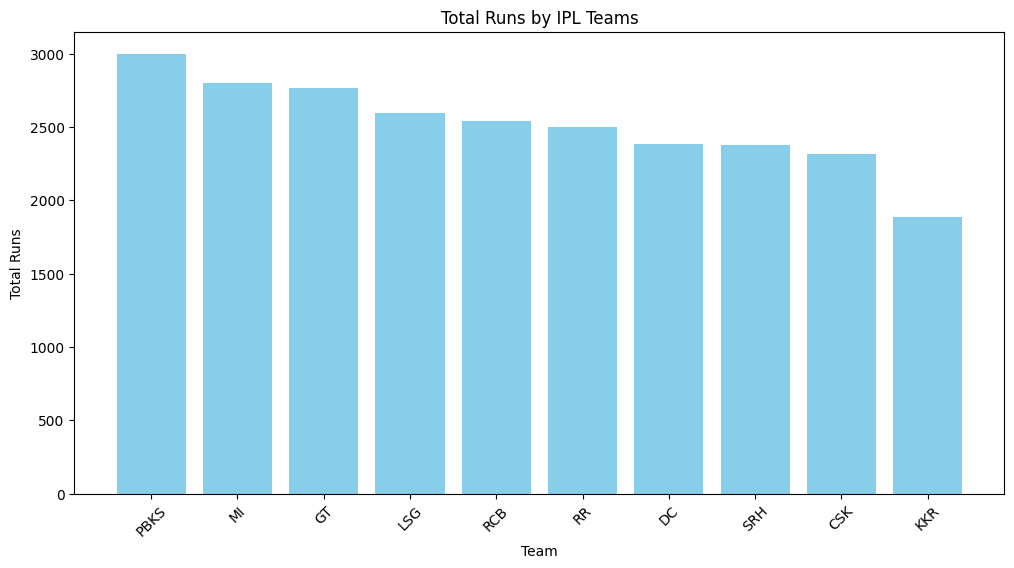

In [12]:
plt.figure(figsize=(12,6))
plt.bar(team_stats['Team'], team_stats['Runs'], color='skyblue')
plt.xlabel('Team')
plt.ylabel('Total Runs')
plt.title('Total Runs by IPL Teams')
plt.xticks(rotation=45)
plt.show()

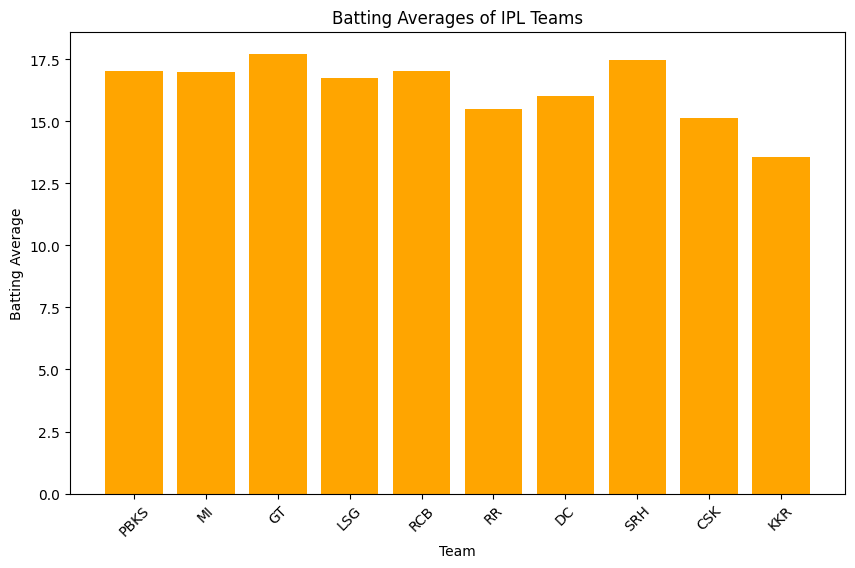

In [13]:
plt.figure(figsize=(10,6))
plt.bar(team_stats['Team'], team_stats['average'], color='orange')
plt.xlabel('Team')
plt.ylabel('Batting Average')
plt.title('Batting Averages of IPL Teams')
plt.xticks(rotation=45)
plt.show()

In [14]:
team_stats2 = pd.merge(team_Wickets, team_Matches,  on='Team')
team_stats2

,Team,WKT,Matches
0,CSK,80,153
1,DC,67,149
2,GT,87,156
3,KKR,78,139
4,LSG,76,155
5,MI,109,165
6,PBKS,95,176
7,RCB,91,149
8,RR,65,161
9,SRH,81,136


In [15]:
team_stats2['average'] = team_stats2['WKT'] / team_stats2['Matches']
print("Team Performance Statistics:\n", team_stats2)

Team Performance Statistics:
    Team  WKT  Matches   average
0   CSK   80      153  0.522876
1    DC   67      149  0.449664
2    GT   87      156  0.557692
3   KKR   78      139  0.561151
4   LSG   76      155  0.490323
5    MI  109      165  0.660606
6  PBKS   95      176  0.539773
7   RCB   91      149  0.610738
8    RR   65      161  0.403727
9   SRH   81      136  0.595588


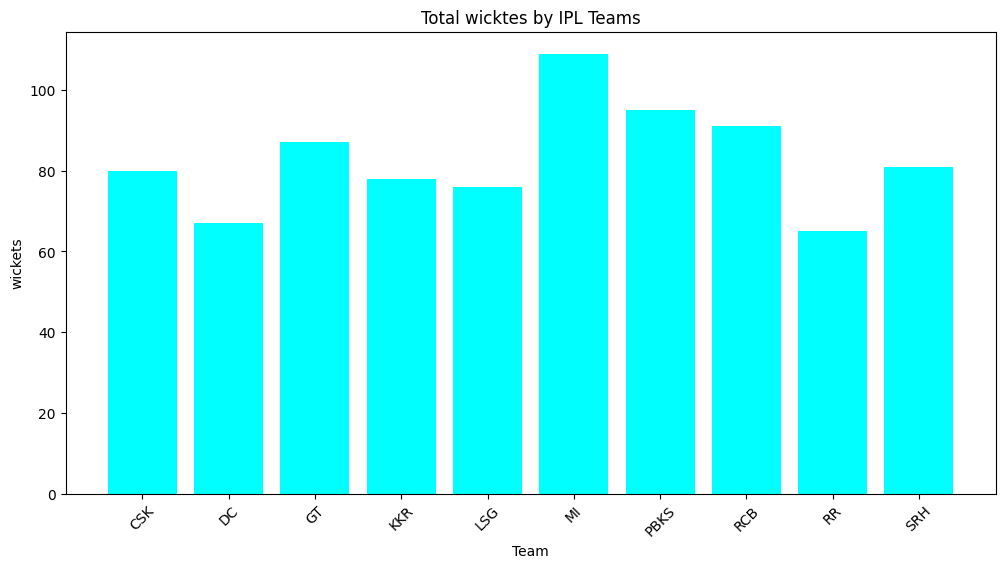

In [16]:
plt.figure(figsize=(12,6))
plt.bar(team_stats2['Team'], team_stats2['WKT'], color='aqua')
plt.xlabel('Team')
plt.ylabel('wickets')
plt.title('Total wicktes by IPL Teams')
plt.xticks(rotation=45)
plt.show()

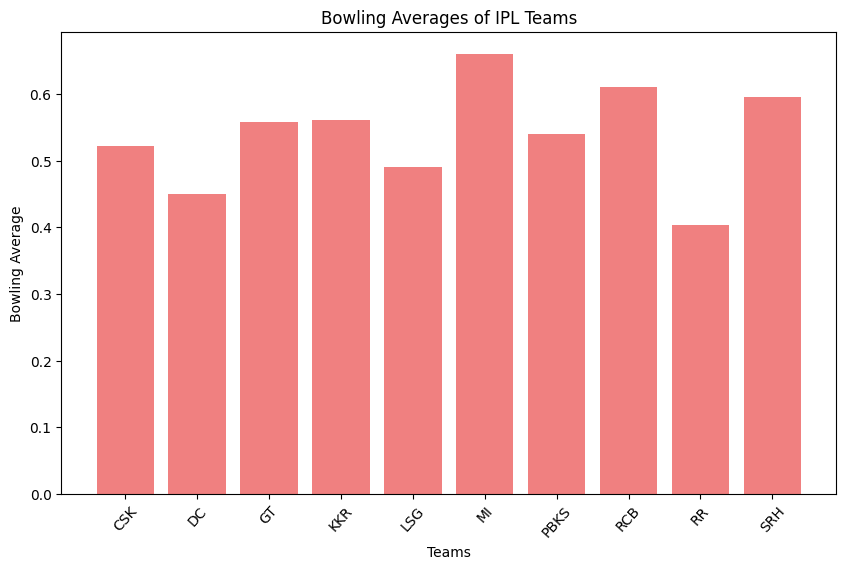

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(team_stats2['Team'], team_stats2['average'], color='lightcoral')
plt.xlabel('Teams')
plt.ylabel('Bowling Average')
plt.title('Bowling Averages of IPL Teams')
plt.xticks(rotation=48)
plt.show()

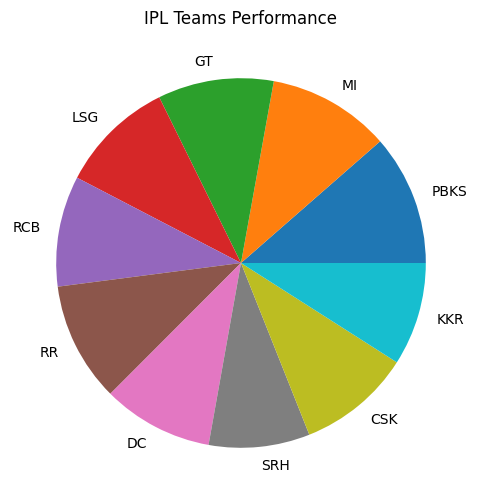

In [ ]:
plt.figure(figsize=(10,6))
plt.pie(team_stats['Matches'], labels=team_stats['Team'], autopct='')
plt.title('IPL Teams Performance')
plt.show()


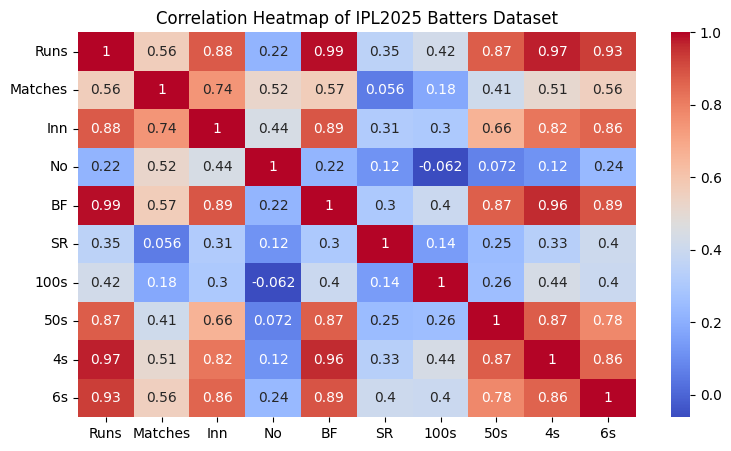

In [ ]:
df = pd.read_csv("IPL2025Batters.csv")

# Compute correlation matrix of numeric columns
k = df.select_dtypes(include=[float, int]).corr()

# Plot heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(k, annot=True, cmap="coolwarm")  # You can change the colormap to your preference
plt.title('Correlation Heatmap of IPL2025 Batters Dataset')
plt.show()


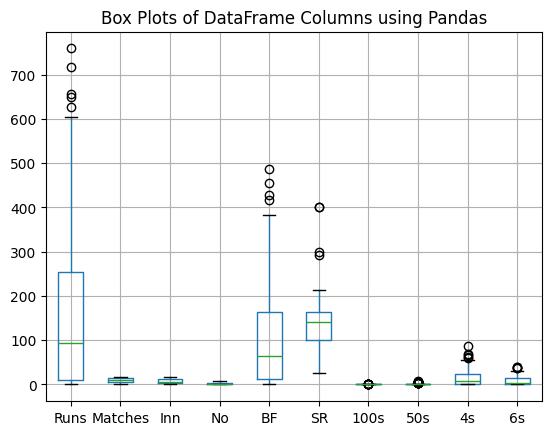

In [ ]:
df.boxplot()
plt.title("Box Plots of DataFrame Columns using Pandas")
plt.show()